<a href="https://colab.research.google.com/github/GabrielAlvesdata/analise-violencia-brasil/blob/main/mapa_violencia_brasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mapa da Violência no Brasil

Projeto de análise de dados utilizando Python para analisar padrões de violência no Brasil.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
!pip install folium

In [30]:
print("Projeto iniciado com sucesso!")

Projeto iniciado com sucesso!


## 1. Importando bibliotecas

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [32]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/2014_usa_states.csv"

df = pd.read_csv(url)

df.head()

,Rank,State,Postal,Population
0,1,Alabama,AL,4849377.0
1,2,Alaska,AK,736732.0
2,3,Arizona,AZ,6731484.0
3,4,Arkansas,AR,2966369.0
4,5,California,CA,38802500.0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        52 non-null     int64  
 1   State       52 non-null     object 
 2   Postal      52 non-null     object 
 3   Population  52 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.8+ KB


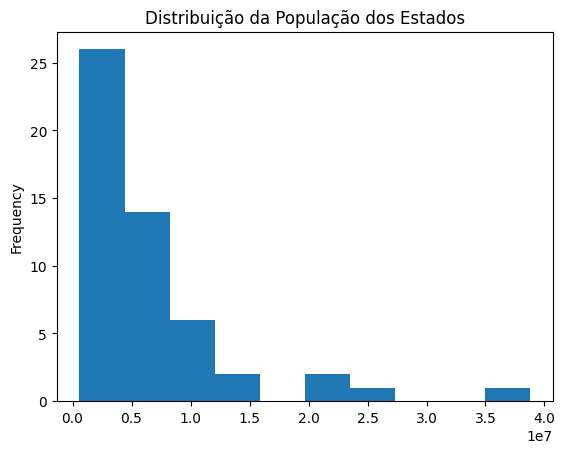

In [34]:
import matplotlib.pyplot as plt

df["Population"].plot(kind="hist")

plt.title("Distribuição da População dos Estados")
plt.show()

## 2. Análise Exploratoria de Sados (EUA)

In [35]:
df.head(10)

,Rank,State,Postal,Population
0,1,Alabama,AL,4849377.0
1,2,Alaska,AK,736732.0
2,3,Arizona,AZ,6731484.0
3,4,Arkansas,AR,2966369.0
4,5,California,CA,38802500.0
5,6,Colorado,CO,5355866.0
6,7,Connecticut,CT,3596677.0
7,8,Delaware,DE,935614.0
8,9,District of Columbia,DC,658893.0
9,10,Florida,FL,19893297.0


In [36]:
df.describe()

,Rank,Population
count,52.000000,5.200000e+01
mean,26.500000,6.200105e+06
std,15.154757,7.063774e+06
min,1.000000,5.841530e+05
25%,13.750000,1.796360e+06
50%,26.500000,4.191848e+06
75%,39.250000,6.824438e+06
max,52.000000,3.880250e+07


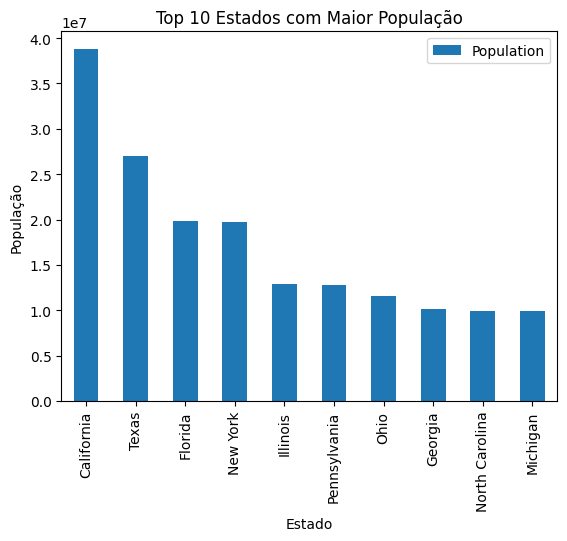

In [37]:
import matplotlib.pyplot as plt

df.sort_values("Population", ascending=False).head(10).plot(
    x="State"
    ,y="Population"
    ,kind="bar"
)

plt.title("Top 10 Estados com Maior População")
plt.xlabel("Estado")
plt.ylabel("População")
plt.show()

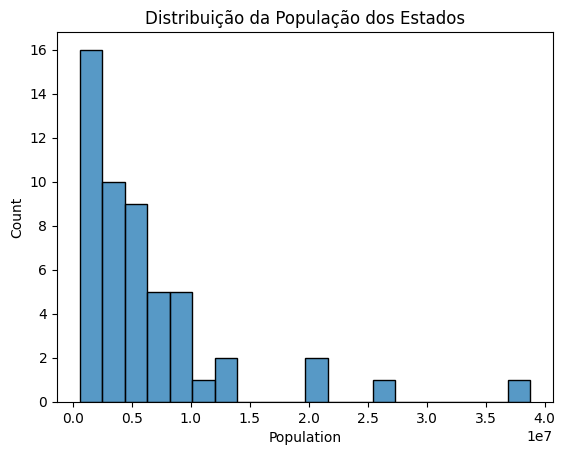

<Figure size 640x480 with 0 Axes>

In [66]:
import seaborn as sns

sns.histplot(df["Population"], bins=20)

plt.title("Distribuição da População dos Estados")
plt.show()

plt.savefig("grafico_populacao.png")

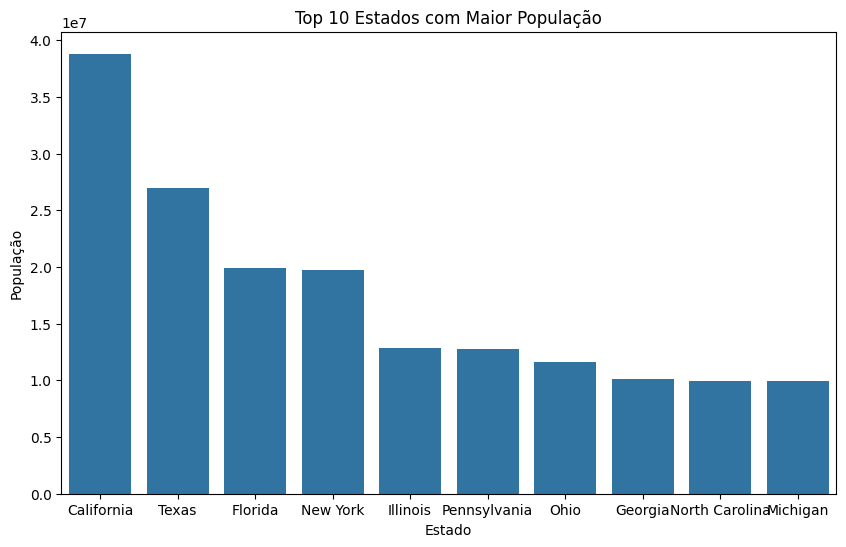

In [39]:
top10 = df.sort_values("Population", ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x="State", y="Population", data=top10)

plt.title("Top 10 Estados com Maior População")
plt.xlabel("Estado")
plt.ylabel("População")
plt.show()



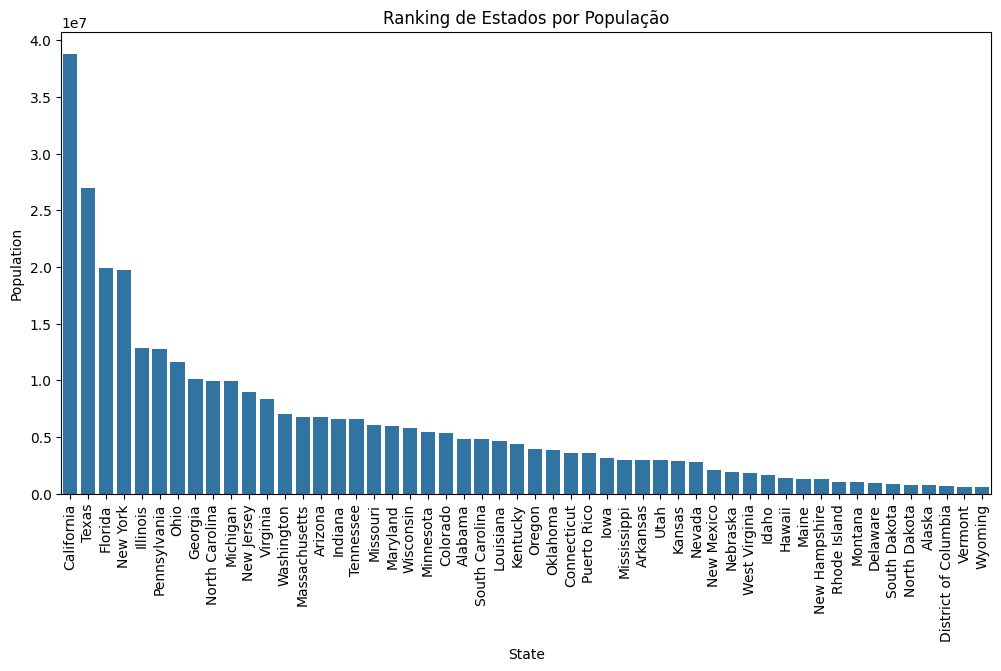

In [40]:
df_sorted = df.sort_values("Population", ascending=False)
plt.figure(figsize=(12,6))

sns.barplot(x="State", y="Population", data=df_sorted)

plt.xticks(rotation=90)
plt.title("Ranking de Estados por População")

plt.show()


## Insight da análise

Observa-se que alguns estados concetram grande parte da população.
Isso indica que a concentração populacional em determinadas regiões,
o que pode impactar a infraestrutura, economia e políticas públicas.

In [41]:
import folium

In [42]:
mapa_brasil = folium.Map(
    location=[-14.2350, - 51.9253],
    zoom_start=4
)

mapa_brasil

In [44]:
folium.Marker(
    location=[-23.5505, - 46.6333],
    popup="São Paulo",
    tooltip="Clique Aqui"
).add_to(mapa_brasil)

mapa_brasil

In [45]:
folium.Marker([-22.9068, -43.1729], popup="Rio de Janeiro").add_to(mapa_brasil)
folium.Marker([-15.7939, -47.8828], popup="Brasiília").add_to(mapa_brasil)

mapa_brasil

In [46]:
mapa_brasil.save("mapa_brasil.html")

In [47]:
import pandas as pd

dados = {
    "cidades":["São Paulo", "Rio de Janeiro", "Brasilia", "Salvador", "Fortaleza"],
    "lat":[-23.5505, -22.9068, -15.7939, -13.0000, -3.7319],
    "lon":[-46.6333, -43.1729, -47.8828, -38.5000, -38.5437]
}

df_cidades = pd.DataFrame(dados)

df_cidades

,cidades,lat,lon
0,São Paulo,-23.5505,-46.6333
1,Rio de Janeiro,-22.9068,-43.1729
2,Brasilia,-15.7939,-47.8828
3,Salvador,-13.0000,-38.5000
4,Fortaleza,-3.7319,-38.5437


In [48]:
import folium

mapa = folium.Map(location=[-14.2350, -51.9253], zoom_start=4)

mapa

In [49]:
for _, row in df_cidades.iterrows():
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=row["cidades"]
    ).add_to(mapa)

mapa

## Visualização geográfico

Neste mapa foram adicionadas algumas cidades brasileiras
ultilizando a biblioteca Folium para visualização geografica

In [50]:
from folium.plugins import HeatMap

In [56]:
dados_calor = [
   [-23.5505, - 46.6333, 100], # São Paulo
   [- 22.9068, - 43.1729, 80], # Rio de janeiro
   [-15.7939,-47.8828, 60 ], # Brasília
   [-13.0000,	-38.5000, 70], # Salvador
   [-3.7319,	-38.5437, 50] # Fortaleza
]

In [53]:
mapa_calor = folium.Map(
    location=[-14.2350, -51.9253],
    zoom_start=4
)

In [64]:
HeatMap(dados_calor).add_to(mapa_calor)

mapa_calor


## Heatmap de ocorrências
Foi criado um mapa de calor para visualizar regiões  com maior intensidade
de ocorrências. Áreas mais quente indicam maior concetraçãp de eventos

In [58]:
mapa_calor.save("Mapa_violencia_brasil.html")

In [60]:
from google.colab import files
files.download("Mapa_violencia_brasil.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>